# pycycle Tutorial

**pycycle** is a hybrid Lomb-Scargle / Lafler-Kinman period finder for multiband variable-star light curves, based on [Saha & Vivas (2017, AJ 154, 231)](https://doi.org/10.3847/1538-3881/aa73d9).

This notebook walks through a complete period-finding analysis on the bundled B1392 RR Lyrae dataset.

**Outline**
1. Load and inspect the data
2. Run the period search
3. Examine the top period candidates
4. Plot the periodogram
5. Plot the phased light curve
6. Multi-band run (all filters)

In [1]:
import importlib.resources
import numpy as np
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt

from pycycle import PeriodSearch, __version__

print('pycycle version:', __version__)

pycycle version: 0.24.0


## 1. Load and inspect the data

The package bundles a SDSS-stripe-82 light curve for the RR Lyrae candidate **B1392** (373 observations, 5 filter bands: *u g r i z* coded as integers 0–4).

In [2]:
data_path = importlib.resources.files('pycycle.data').joinpath('B1392all.tab')
hjd, mag, magerr, filts = np.loadtxt(str(data_path), unpack=True)

# Standard quality cut: keep observations with 0 <= magerr <= 0.2
ok = (magerr >= 0.0) & (magerr <= 0.2)
hjd, mag, magerr, filts = hjd[ok], mag[ok], magerr[ok], filts[ok]

filtnams = ['u', 'g', 'r', 'i', 'z']

print(f'Total observations after quality cut: {len(hjd)}')
print(f'HJD range: {hjd.min():.1f} – {hjd.max():.1f}  ({hjd.max()-hjd.min():.0f} days)')
print(f'Magnitude range: {mag.min():.2f} – {mag.max():.2f}')
print('Obs per filter:', {f: int((filts == i).sum()) for i, f in enumerate(filtnams)})

Total observations after quality cut: 368
HJD range: 56423.7 – 57116.9  (693 days)
Magnitude range: 21.52 – 28.20
Obs per filter: {'u': 57, 'g': 68, 'r': 69, 'i': 94, 'z': 80}


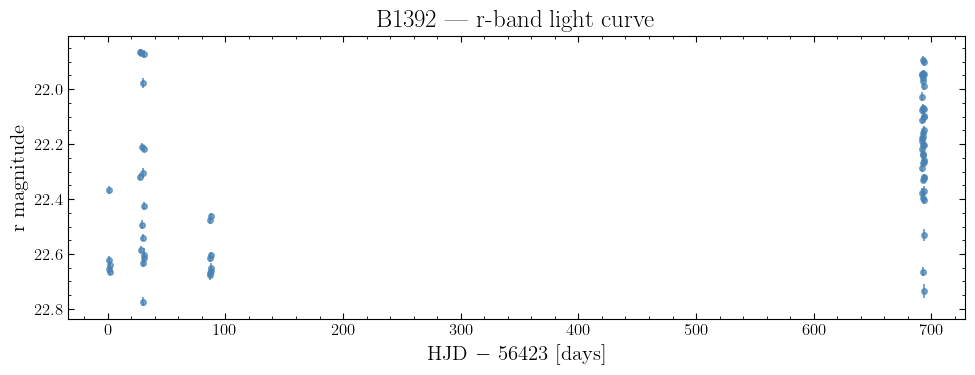

In [3]:
# Quick look at the raw light curve (r-band)
r_ok = filts == 2
hjd0 = int(hjd.min())

fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(hjd[r_ok] - hjd0, mag[r_ok], yerr=magerr[r_ok],
            fmt='o', ms=4, alpha=0.7, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel(f'HJD − {hjd0} [days]')
ax.set_ylabel('r magnitude')
ax.set_title('B1392 — r-band light curve')
plt.tight_layout()
plt.show()

## 2. Run the period search (single band — r)

Key parameters:
- `pmin` — minimum period to test [days]
- `dphi` — maximum allowed phase step between consecutive test periods (controls grid density)
- `n_thresh` — Monte Carlo significance runs (0 = skip threshold; use ≥1 in production)

In [4]:
ps_r = PeriodSearch(hjd, mag, magerr, filts, filtnams=['r'])
result_r = ps_r.run(pmin=0.2, dphi=0.02, n_thresh=1)

print(f'\nBest period (r-band): {result_r.best_period:.7f} days')

PeriodSearch: backend = C/Cython

PeriodSearch: filter r
periodogram: BEGIN
periodogram: period range     0.20000153 –   346.62265500 days
periodogram: 173211 test periods
periodogram: 57 observations for filter 0
scargle: done  0.446 s
ctheta_slave: done  0.200 s
periodogram: threshold run 1 / 1
periodogram: END

Best period (r-band): 0.5012330 days


## 3. Top period candidates

In [5]:
top = result_r.top_periods(n=10)
top.pprint_all()

rank       period             period_err             power        index        freq              thresh      
---- ------------------ ---------------------- ------------------ ----- ------------------ ------------------
   1 0.5012329800156161 3.6239822139294553e-06  203.1761435761325 69054  1.995080211938258  5.263164354228389
   2 0.5012474765733446  3.624191839635138e-06 181.99173211102357 69052 1.9950225123052086  4.342101884892125
   3  0.501610163236953 3.6294383980450817e-06  177.3205118757019 69002 1.9935800214789814  4.774624281237999
   4 0.5020024548140413 3.6351174876880776e-06 165.70654138295913 68948 1.9920221313866562 3.6235358603928614
   5 0.5016392008451752  3.629858614739856e-06 165.15972193225488 68998 1.9934646222128836  4.836361215729034
   6 1.0108858671877254 1.4740243032718148e-05 150.45269866662954 34189 0.9892313588100605 2.0448214625573016
   7 0.5008636008958879 3.6186428987172725e-06 144.50371301250314 69105 1.9965515525810094  5.619267914370274
   8 1.009

## 4. Plot the PSI periodogram

The PSI statistic combines the Lomb-Scargle power (sensitive to sinusoidal variations) with the Lafler-Kinman phase-dispersion (works for any light-curve shape). The red line is the significance threshold.

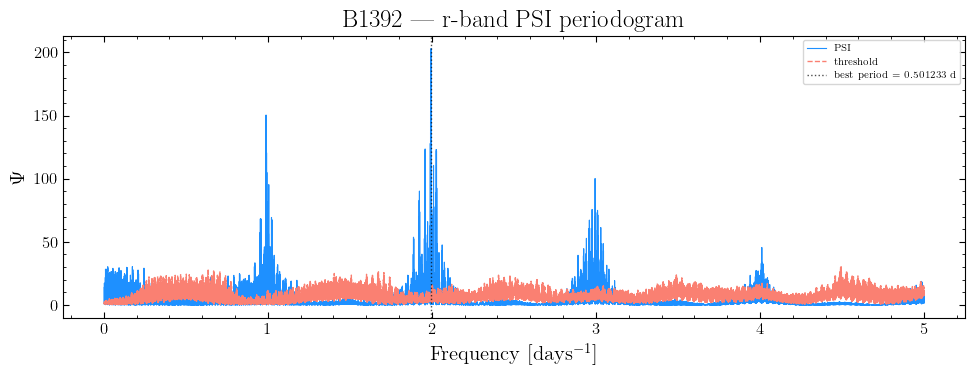

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result_r.freq, result_r.psi_m, color='dodgerblue', lw=0.8, label='PSI')
if np.any(result_r.thresh_m):
    ax.plot(result_r.freq, result_r.thresh_m, color='salmon', lw=1, ls='--', label='threshold')
ax.axvline(1.0 / result_r.best_period, color='k', lw=1, ls=':', alpha=0.7,
           label=f'best period = {result_r.best_period:.6f} d')
ax.set_xlabel(r'Frequency [days$^{-1}$]')
ax.set_ylabel(r'$\Psi$')
ax.set_title('B1392 — r-band PSI periodogram')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Phase-folded light curve

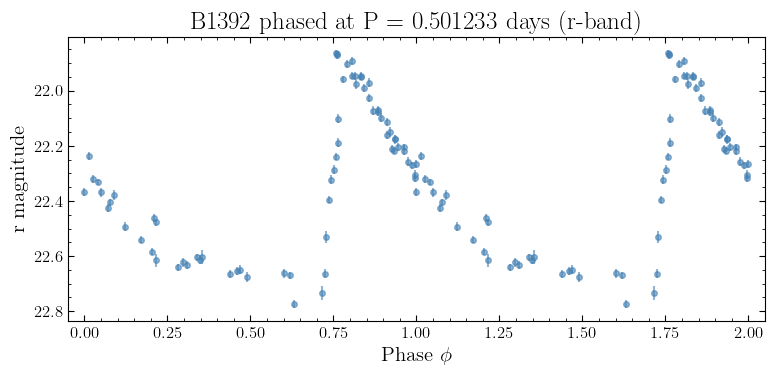

In [7]:
period = result_r.best_period
r_ok = filts == 2

phi = ((hjd[r_ok] - hjd[r_ok].min()) / period) % 1.0

fig, ax = plt.subplots(figsize=(8, 4))
for offset in [0, 1]:   # show two cycles
    ax.errorbar(phi + offset, mag[r_ok], yerr=magerr[r_ok],
                fmt='o', ms=4, alpha=0.6, color='steelblue')
ax.invert_yaxis()
ax.set_xlim(-0.05, 2.05)
ax.set_xlabel(r'Phase $\phi$')
ax.set_ylabel('r magnitude')
ax.set_title(f'B1392 phased at P = {period:.6f} days (r-band)')
plt.tight_layout()
plt.show()

## 6. Multi-band run (all five SDSS filters)

Running across all filters simultaneously yields a combined PSI that is more robust against period aliases.

In [8]:
ps_all = PeriodSearch(hjd, mag, magerr, filts, filtnams=['u', 'g', 'r', 'i', 'z'])
result_all = ps_all.run(pmin=0.2, dphi=0.02, n_thresh=1)

print(f'\nBest period (all bands): {result_all.best_period:.7f} days')
print(f'Gold value:              0.5016247 days')

PeriodSearch: backend = C/Cython

PeriodSearch: filter u
periodogram: BEGIN
periodogram: period range     0.20000153 –   346.62265500 days
periodogram: 173211 test periods
periodogram: 57 observations for filter 0
scargle: done  0.446 s
ctheta_slave: done  0.200 s
periodogram: threshold run 1 / 1
periodogram: END

PeriodSearch: filter g
periodogram: BEGIN
periodogram: period range     0.20000153 –   346.62265500 days
periodogram: 173211 test periods
periodogram: 68 observations for filter 1
scargle: done  0.531 s
ctheta_slave: done  0.254 s
periodogram: threshold run 1 / 1
periodogram: END

PeriodSearch: filter r
periodogram: BEGIN
periodogram: period range     0.20000153 –   346.62265500 days
periodogram: 173211 test periods
periodogram: 69 observations for filter 2
scargle: done  0.530 s
ctheta_slave: done  0.257 s
periodogram: threshold run 1 / 1
periodogram: END

PeriodSearch: filter i
periodogram: BEGIN
periodogram: period range     0.20000153 –   346.62265500 days
periodogram: 17

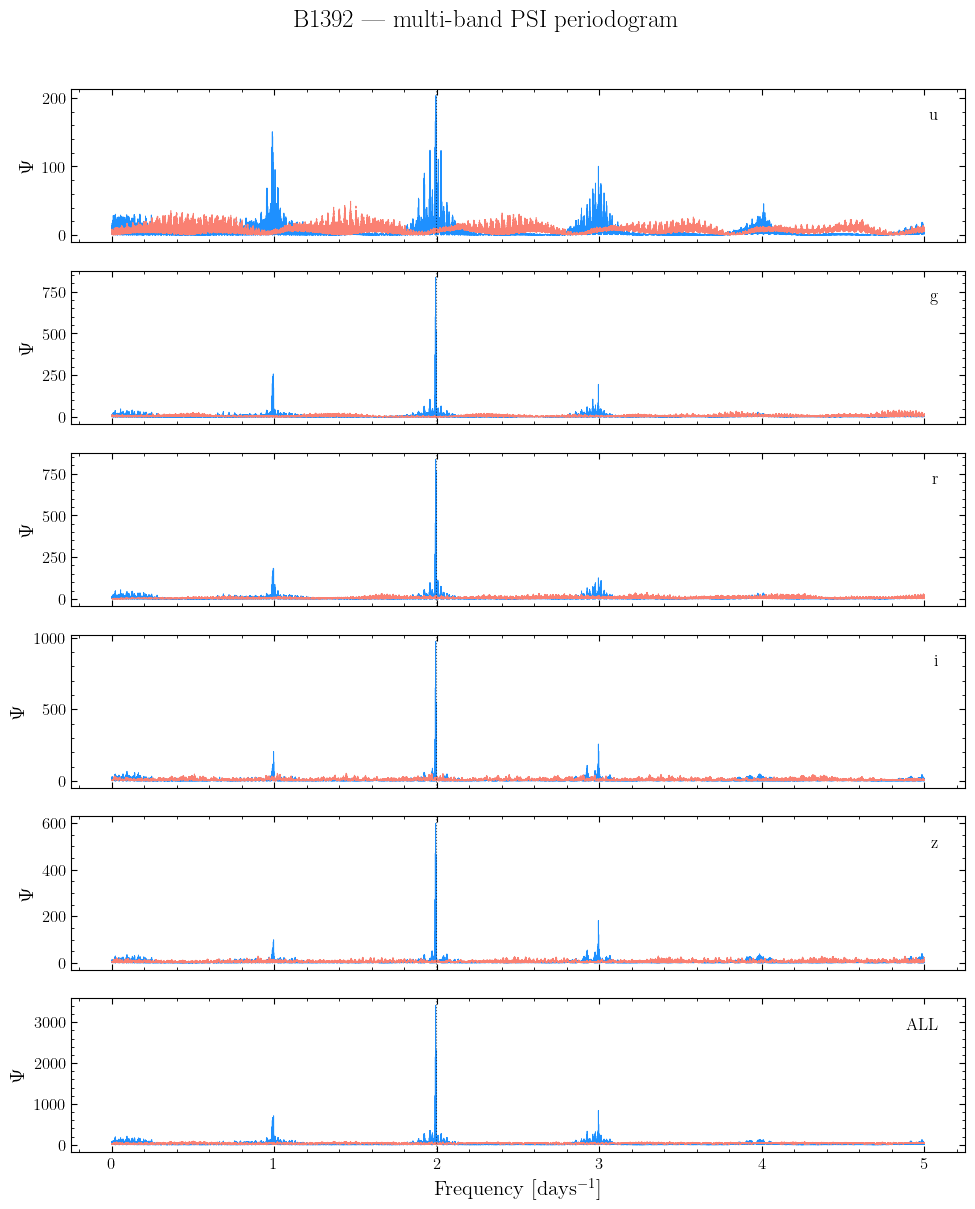

In [9]:
# Per-filter + combined periodogram
nfilts = len(filtnams)
psi_combined = result_all.psi_m.sum(axis=0)
thresh_combined = result_all.thresh_m.sum(axis=0)

fig, axes = plt.subplots(nfilts + 1, 1, sharex=True, figsize=(10, 12))
for i, (ax, fn) in enumerate(zip(axes[:nfilts], filtnams)):
    ax.plot(result_all.freq, result_all.psi_m[i], color='dodgerblue', lw=0.7)
    if np.any(result_all.thresh_m[i]):
        ax.plot(result_all.freq, result_all.thresh_m[i], color='salmon', lw=0.8, ls='--')
    ax.text(0.97, 0.80, fn, transform=ax.transAxes, ha='right', fontsize=12)
    ax.set_ylabel(r'$\Psi$')

axes[-1].plot(result_all.freq, psi_combined, color='dodgerblue', lw=0.7)
if np.any(thresh_combined):
    axes[-1].plot(result_all.freq, thresh_combined, color='salmon', lw=0.8, ls='--')
axes[-1].text(0.97, 0.80, 'ALL', transform=axes[-1].transAxes, ha='right', fontsize=12)
axes[-1].set_ylabel(r'$\Psi$')
axes[-1].set_xlabel(r'Frequency [days$^{-1}$]')

for ax in axes:
    ax.axvline(1.0 / result_all.best_period, color='k', lw=0.8, ls=':', alpha=0.6)

fig.suptitle('B1392 — multi-band PSI periodogram', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Top 5 periods from the combined run
result_all.top_periods(n=5).pprint_all()

rank       period             period_err             power        index        freq              thresh      
---- ------------------ ---------------------- ------------------ ----- ------------------ ------------------
   1 0.5016246816208382 3.6296484972608845e-06  3411.898190285032 69000 1.9935223218459326 30.221042007692148
   2 0.5012402281896653  3.624087024589606e-06 2324.1879748975457 69053  1.995051362121733 27.690384415826813
   3 0.5020169959157651 3.6353280802314814e-06 2149.1337828297515 68946 1.9919644317536072 35.348733239277244
   4 0.5024026422970435 3.6409154585692605e-06 1204.9108002430182 68893 1.9904353914778063  37.62128899478716
   5 0.5008636008958879 3.6186428987172725e-06 1173.5024039928971 69105 1.9965515525810094 24.806739837737105


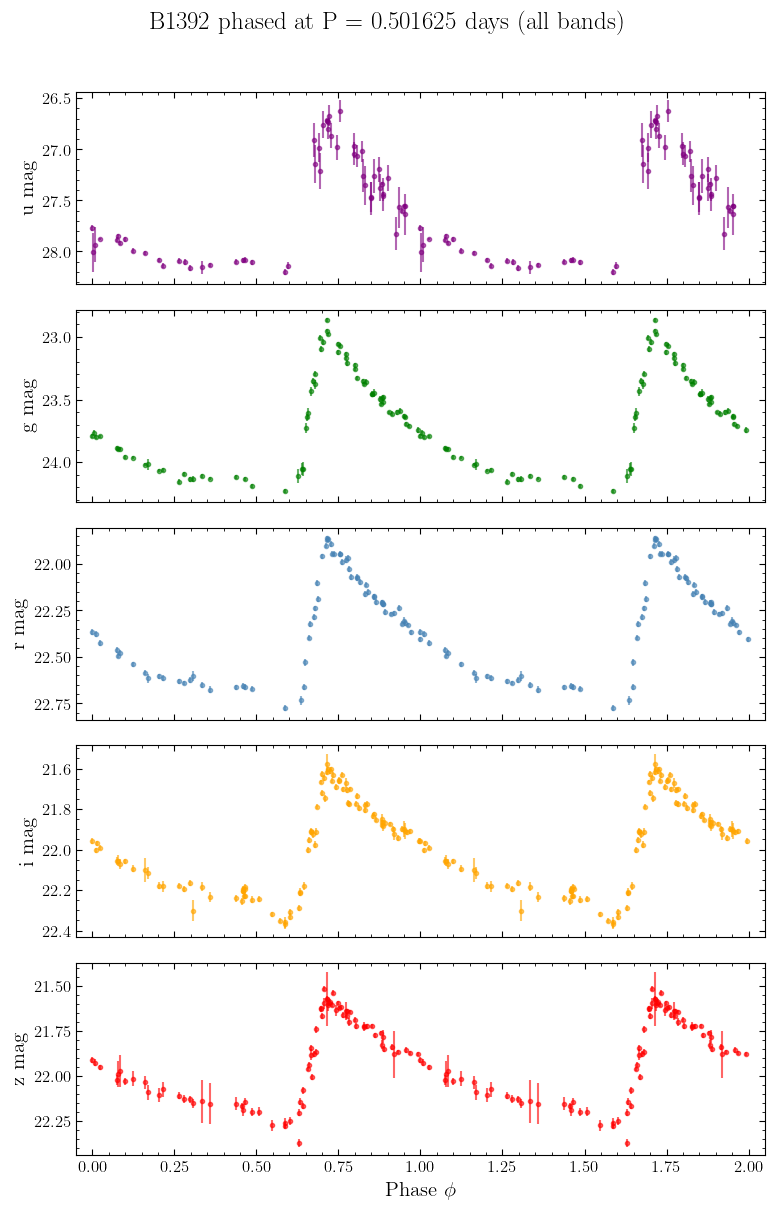

In [11]:
# Phase-fold all bands at the best combined period
period = result_all.best_period
colors = ['purple', 'green', 'steelblue', 'orange', 'red']

fig, axes = plt.subplots(nfilts, 1, sharex=True, figsize=(8, 12))
for i, (ax, fn, c) in enumerate(zip(axes, filtnams, colors)):
    mask = filts == float(i)
    phi = ((hjd[mask] - hjd[mask].min()) / period) % 1.0
    for offset in [0, 1]:
        ax.errorbar(phi + offset, mag[mask], yerr=magerr[mask],
                    fmt='o', ms=3, alpha=0.6, color=c)
    ax.invert_yaxis()
    ax.set_ylabel(f'{fn} mag')
    ax.set_xlim(-0.05, 2.05)

axes[-1].set_xlabel(r'Phase $\phi$')
fig.suptitle(f'B1392 phased at P = {period:.6f} days (all bands)', y=1.01)
plt.tight_layout()
plt.show()